# Experiment 5 – Unsupervised Learning
**ENCS5141 – Machine Learning and Data Science**  
Birzeit University

---

This notebook covers:
- K-Means Clustering
- DBSCAN Clustering
- Gaussian Mixture Models (GMM)
- Quantitative Evaluation of Clustering Methods
- **ToDo 1:** Two Moons Dataset
- **ToDo 2:** K-Means vs K-Medoids
- **ToDo 3:** Image Segmentation with K-Means

## 0. Imports

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn import metrics
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

---
## 1. Data Generation – Blobs

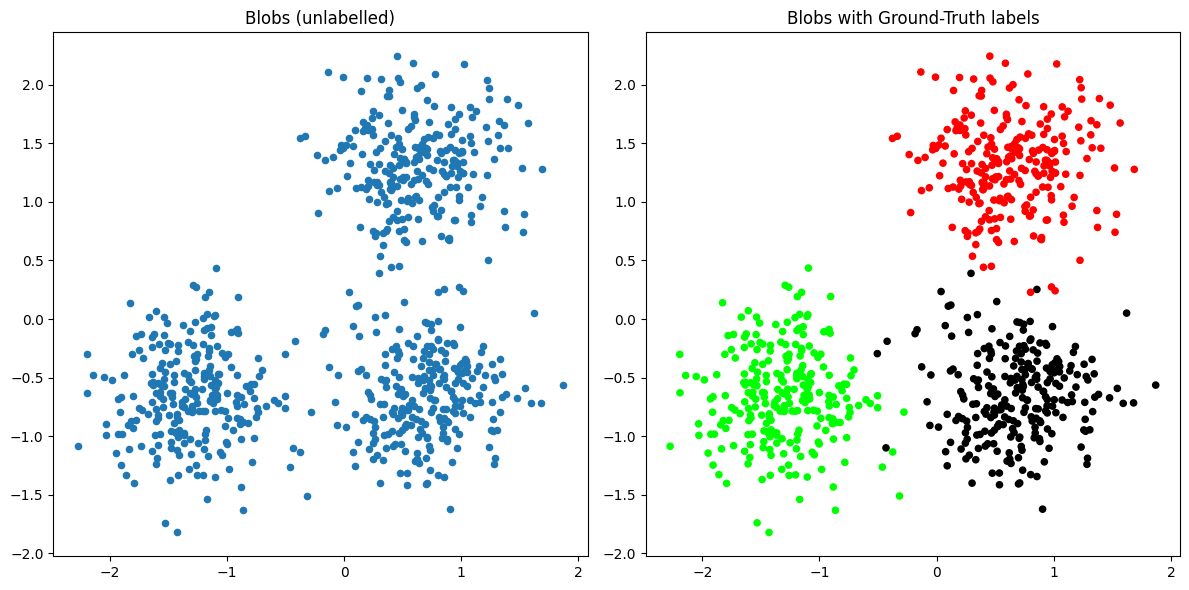

In [31]:
# ── Generate a Gaussian 2D dataset (blobs) ──────────────────────────────────
centers = [[1, 1], [-1, -1], [1, -1]]
X_blobs, labels_blobs = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0)
X_blobs = StandardScaler().fit_transform(X_blobs)

colormap = np.array(['red', 'lime', 'black'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=20)
plt.title('Blobs (unlabelled)')

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[labels_blobs], s=20)
plt.title('Blobs with Ground-Truth labels')

plt.tight_layout()
plt.show()

---
## 2. K-Means Clustering on Blobs

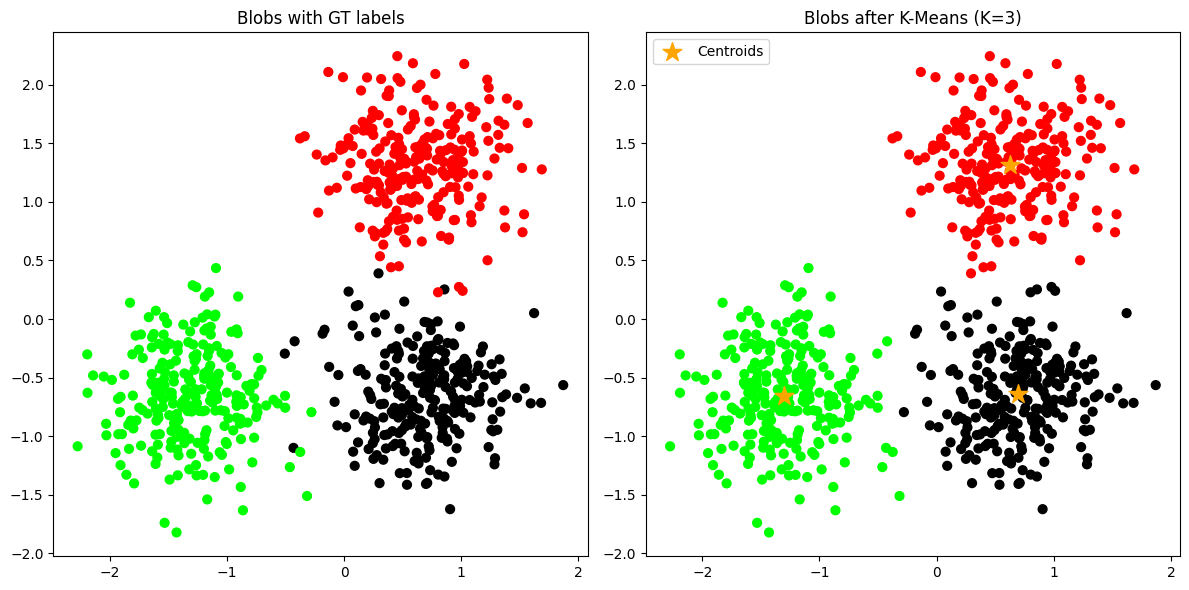

In [32]:
# ── Fit KMeans with K = 3 ───────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_blobs)
predY_kmeans = np.choose(kmeans.labels_, [0, 1, 2]).astype(np.int64)
k_means_cluster_centers = kmeans.cluster_centers_

# ── Visualise ───────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[labels_blobs], s=40)
plt.title('Blobs with GT labels')

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[predY_kmeans], s=40)
plt.scatter(k_means_cluster_centers[:, 0],
            k_means_cluster_centers[:, 1],
            marker='*', c='orange', s=200, zorder=5, label='Centroids')
plt.legend()
plt.title('Blobs after K-Means (K=3)')

plt.tight_layout()
plt.show()

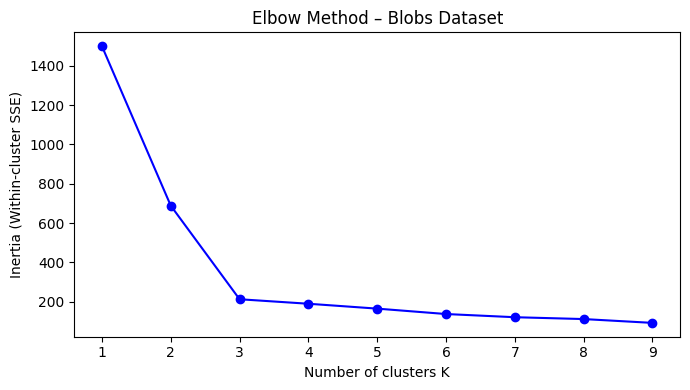

In [33]:
# ── Try different values of K (Elbow method) ────────────────────────────────
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.title('Elbow Method – Blobs Dataset')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

---
## 3. DBSCAN Clustering on Blobs

In [34]:
# ── Fit DBSCAN ──────────────────────────────────────────────────────────────
db = DBSCAN(eps=0.3, min_samples=10).fit(X_blobs)
labels_db = db.labels_

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db   = list(labels_db).count(-1)
print(f"Estimated number of clusters : {n_clusters_db}")
print(f"Estimated number of noise pts: {n_noise_db}")

Estimated number of clusters : 3
Estimated number of noise pts: 18


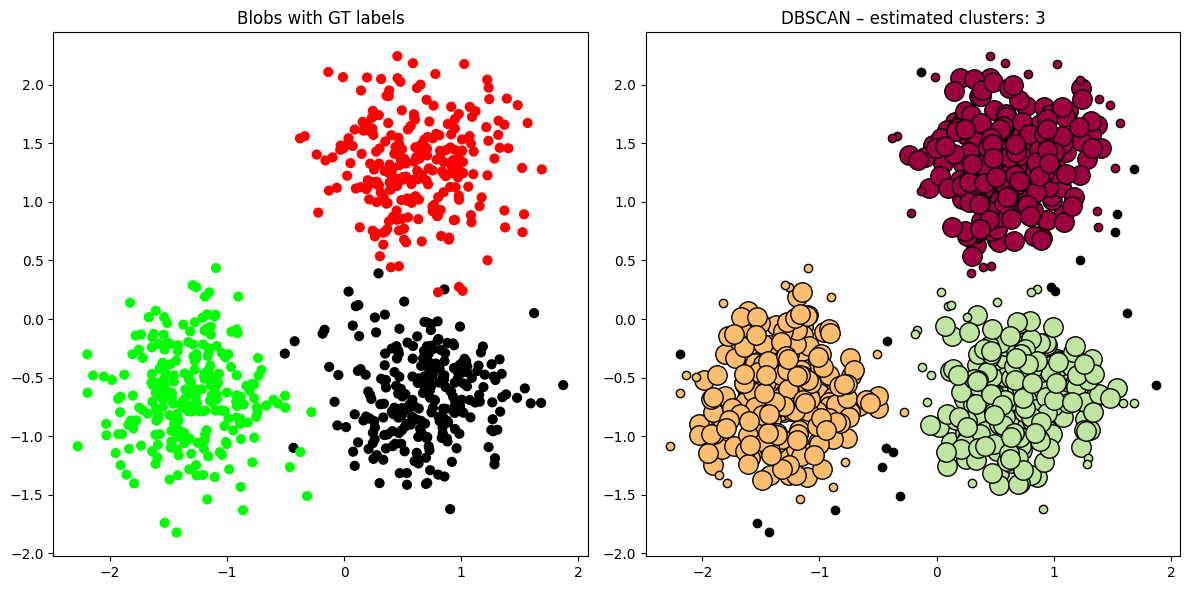

In [35]:
# ── Visualise ───────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[labels_blobs], s=40)
plt.title('Blobs with GT labels')

plt.subplot(1, 2, 2)
unique_labels = set(labels_db)
core_mask = np.zeros_like(labels_db, dtype=bool)
core_mask[db.core_sample_indices_] = True
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # noise → black
    mask = labels_db == k
    # core points – large markers
    xy = X_blobs[mask & core_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o',
             markerfacecolor=tuple(col), markeredgecolor='k', markersize=14)
    # border / noise points – small markers
    xy = X_blobs[mask & ~core_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o',
             markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)

plt.title(f'DBSCAN – estimated clusters: {n_clusters_db}')
plt.tight_layout()
plt.show()

---
## 4. Gaussian Mixture Model (GMM) on Blobs

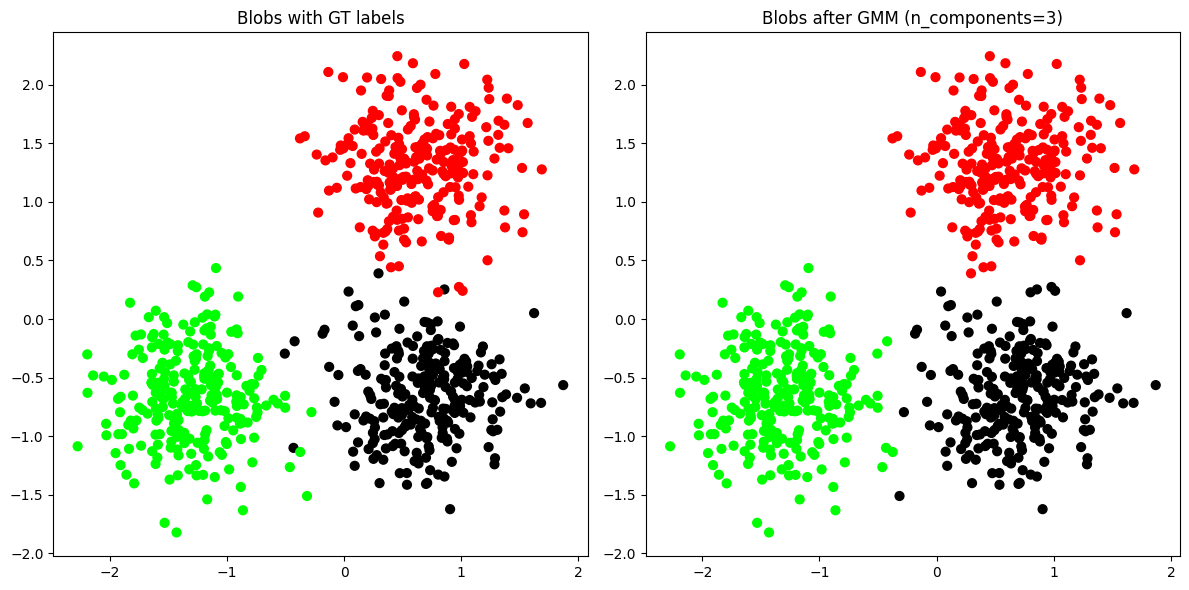

In [36]:
# ── Fit GMM ─────────────────────────────────────────────────────────────────
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(X_blobs)
y_gmm = gmm.predict(X_blobs)

# ── Visualise ───────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[labels_blobs], s=40)
plt.title('Blobs with GT labels')

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[y_gmm], s=40)
plt.title('Blobs after GMM (n_components=3)')

plt.tight_layout()
plt.show()

---
## 5. Quantitative Evaluation – Blobs Dataset

In [37]:
def evaluate_clustering(name, true_labels, pred_labels, X):
    """Print clustering evaluation metrics."""
    print(f"{'─'*40}")
    print(f"{name} – Evaluation Metrics\n")
    print(f"  Homogeneity       : {metrics.homogeneity_score(true_labels, pred_labels):.3f}")
    print(f"  Completeness      : {metrics.completeness_score(true_labels, pred_labels):.3f}")
    print(f"  V-measure         : {metrics.v_measure_score(true_labels, pred_labels):.3f}")
    print(f"  Adj. Rand Index   : {metrics.adjusted_rand_score(true_labels, pred_labels):.3f}")
    print(f"  Adj. Mutual Info  : {metrics.adjusted_mutual_info_score(true_labels, pred_labels):.3f}")
    # Silhouette requires at least 2 clusters; skip for degenerate cases
    unique_preds = len(set(pred_labels)) - (1 if -1 in pred_labels else 0)
    if unique_preds >= 2:
        mask = pred_labels != -1          # exclude noise for DBSCAN
        sil = metrics.silhouette_score(X[mask], pred_labels[mask])
        print(f"  Silhouette Score  : {sil:.3f}")
    else:
        print(f"  Silhouette Score  : N/A (only {unique_preds} cluster)")
    print()

evaluate_clustering("DBSCAN",   labels_blobs, labels_db,     X_blobs)
evaluate_clustering("K-Means",  labels_blobs, predY_kmeans,  X_blobs)
evaluate_clustering("GMM",      labels_blobs, y_gmm,         X_blobs)

────────────────────────────────────────
DBSCAN – Evaluation Metrics

  Homogeneity       : 0.953
  Completeness      : 0.883
  V-measure         : 0.917
  Adj. Rand Index   : 0.952
  Adj. Mutual Info  : 0.916
  Silhouette Score  : 0.664

────────────────────────────────────────
K-Means – Evaluation Metrics

  Homogeneity       : 0.945
  Completeness      : 0.945
  V-measure         : 0.945
  Adj. Rand Index   : 0.968
  Adj. Mutual Info  : 0.945
  Silhouette Score  : 0.650

────────────────────────────────────────
GMM – Evaluation Metrics

  Homogeneity       : 0.939
  Completeness      : 0.939
  V-measure         : 0.939
  Adj. Rand Index   : 0.964
  Adj. Mutual Info  : 0.938
  Silhouette Score  : 0.650



---
## ToDo 1 – Two Moons Dataset

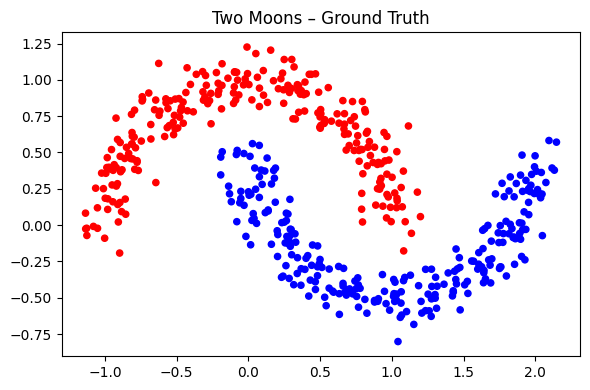

In [38]:
# ── Generate Two Moons ──────────────────────────────────────────────────────
X_moons, labels_moons = make_moons(n_samples=500, noise=0.1, random_state=0)
colormap2 = np.array(['red', 'blue'])

plt.figure(figsize=(6, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1],
            c=colormap2[labels_moons], s=20)
plt.title('Two Moons – Ground Truth')
plt.tight_layout()
plt.show()

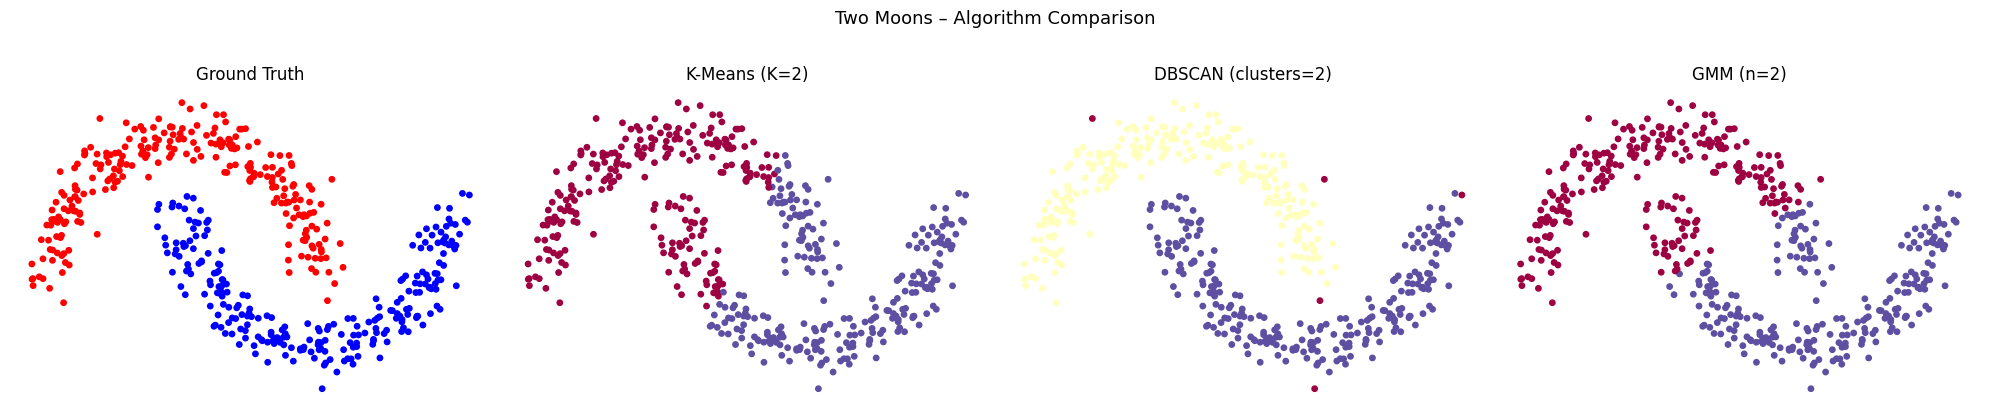

In [39]:
# ── K-Means on Two Moons (K = 2) ────────────────────────────────────────────
km_moons = KMeans(n_clusters=2, random_state=0)
km_moons.fit(X_moons)
pred_km_moons = km_moons.labels_

# ── DBSCAN on Two Moons ─────────────────────────────────────────────────────
db_moons = DBSCAN(eps=0.15, min_samples=5).fit(X_moons)
labels_db_moons = db_moons.labels_
n_clusters_moons = len(set(labels_db_moons)) - (1 if -1 in labels_db_moons else 0)

# ── GMM on Two Moons (n_components = 2) ────────────────────────────────────
gmm_moons = GaussianMixture(n_components=2, random_state=0)
gmm_moons.fit(X_moons)
pred_gmm_moons = gmm_moons.predict(X_moons)

# ── Visualise ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
titles  = ['Ground Truth', 'K-Means (K=2)',
           f'DBSCAN (clusters={n_clusters_moons})', 'GMM (n=2)']
results = [labels_moons, pred_km_moons, labels_db_moons, pred_gmm_moons]
cmaps   = [colormap2, colormap2,
           plt.cm.Spectral(np.linspace(0, 1, len(set(labels_db_moons)))),
           colormap2]

for ax, title, pred in zip(axes, titles, results):
    unique_vals = sorted(set(pred))
    palette = plt.cm.Spectral(np.linspace(0, 1, len(unique_vals)))
    color_arr = np.array([palette[unique_vals.index(p)] for p in pred])
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=color_arr, s=15)
    ax.set_title(title)
    ax.axis('off')

# Override GT plot with proper 2-color
axes[0].cla()
axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=colormap2[labels_moons], s=15)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

plt.suptitle('Two Moons – Algorithm Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [40]:
# ── Quantitative: Two Moons ─────────────────────────────────────────────────
print("\n=== Two Moons Dataset ===")
evaluate_clustering("K-Means",  labels_moons, pred_km_moons,    X_moons)
evaluate_clustering("DBSCAN",   labels_moons, labels_db_moons,  X_moons)
evaluate_clustering("GMM",      labels_moons, pred_gmm_moons,   X_moons)


=== Two Moons Dataset ===
────────────────────────────────────────
K-Means – Evaluation Metrics

  Homogeneity       : 0.192
  Completeness      : 0.192
  V-measure         : 0.192
  Adj. Rand Index   : 0.253
  Adj. Mutual Info  : 0.191
  Silhouette Score  : 0.484

────────────────────────────────────────
DBSCAN – Evaluation Metrics

  Homogeneity       : 0.990
  Completeness      : 0.925
  V-measure         : 0.956
  Adj. Rand Index   : 0.980
  Adj. Mutual Info  : 0.956
  Silhouette Score  : 0.325

────────────────────────────────────────
GMM – Evaluation Metrics

  Homogeneity       : 0.375
  Completeness      : 0.375
  V-measure         : 0.375
  Adj. Rand Index   : 0.472
  Adj. Mutual Info  : 0.374
  Silhouette Score  : 0.468



### Observation – Blobs vs Two Moons

| Dataset | Best Algorithm | Why |
|---------|---------------|-----|
| Blobs   | K-Means / GMM | Convex, roughly spherical, equal-density clusters — exactly the assumption K-Means makes |
| Two Moons | DBSCAN | Non-convex, crescent-shaped clusters — K-Means and GMM fail because they assume elliptical boundaries; DBSCAN uses local density and discovers arbitrary shapes |

K-Means and GMM partition the moons by a linear/elliptical boundary, assigning the overlapping zone incorrectly.  
DBSCAN, with `eps=0.15, min_samples=5`, traces the curved manifold of each moon.

---
## ToDo 2 – K-Means vs K-Medoids (Blobs Dataset)

In [41]:
!pip install scikit-learn-extra -q
from sklearn_extra.cluster import KMedoids

In [42]:
# ── K-Means (already fitted before, just making sure) ───────────────────────
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_blobs)
predY_kmeans = np.choose(kmeans.labels_, [0, 1, 2]).astype(np.int64)
k_means_cluster_centers = kmeans.cluster_centers_

# ── K-Medoids ────────────────────────────────────────────────────────────────
kmedoids = KMedoids(n_clusters=3, random_state=0)
kmedoids.fit(X_blobs)
predY_kmedoids = np.choose(kmedoids.labels_, [0, 1, 2]).astype(np.int64)
kmedoids_centers = kmedoids.cluster_centers_

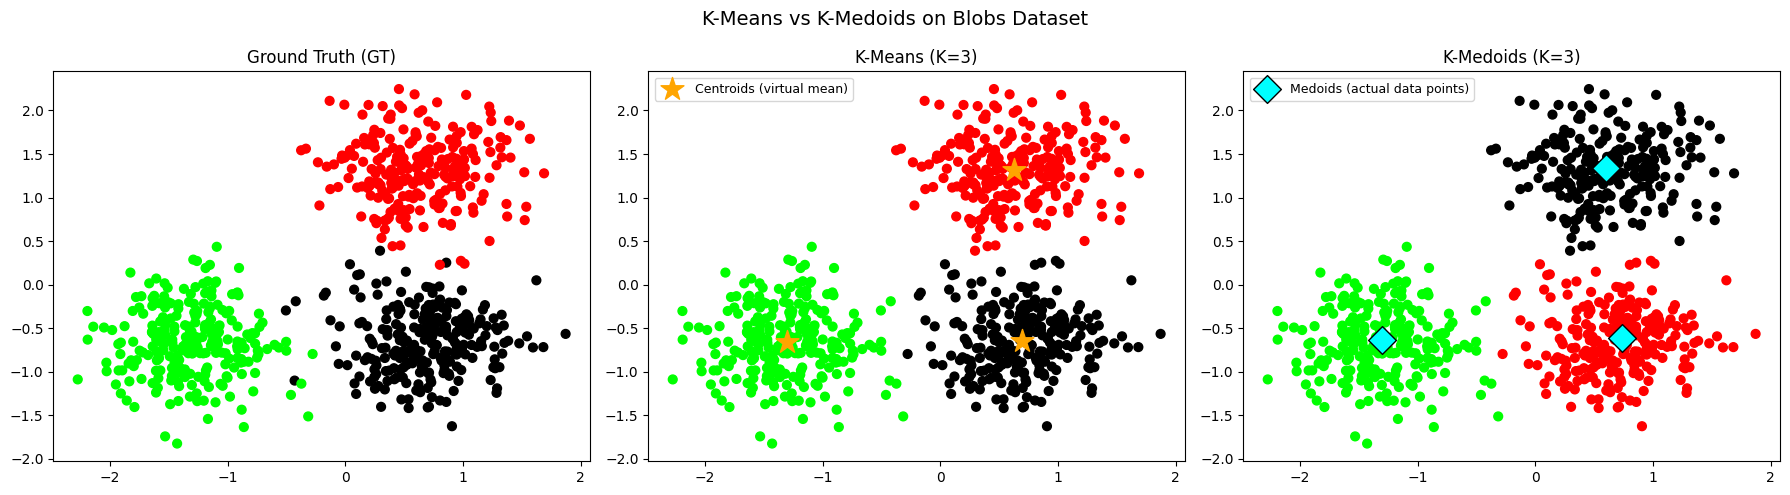

In [43]:
colormap = np.array(['red', 'lime', 'black'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Ground Truth ─────────────────────────────────────────────────────────────
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1],
                c=colormap[labels_blobs], s=40)
axes[0].set_title('Ground Truth (GT)')

# ── K-Means result ───────────────────────────────────────────────────────────
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1],
                c=colormap[predY_kmeans], s=40)
axes[1].scatter(k_means_cluster_centers[:, 0],
                k_means_cluster_centers[:, 1],
                marker='*', c='orange', s=300, zorder=5, label='Centroids (virtual mean)')
axes[1].legend(fontsize=9)
axes[1].set_title('K-Means (K=3)')

# ── K-Medoids result ─────────────────────────────────────────────────────────
axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1],
                c=colormap[predY_kmedoids], s=40)
axes[2].scatter(kmedoids_centers[:, 0],
                kmedoids_centers[:, 1],
                marker='D', c='cyan', edgecolors='k',
                s=200, zorder=5, label='Medoids (actual data points)')
axes[2].legend(fontsize=9)
axes[2].set_title('K-Medoids (K=3)')

plt.suptitle('K-Means vs K-Medoids on Blobs Dataset', fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
from sklearn import metrics

def evaluate_clustering(name, true_labels, pred_labels, X):
    print(f"{'─'*45}")
    print(f"  {name} – Evaluation Metrics\n")
    print(f"  Homogeneity      : {metrics.homogeneity_score(true_labels, pred_labels):.3f}")
    print(f"  Completeness     : {metrics.completeness_score(true_labels, pred_labels):.3f}")
    print(f"  V-measure        : {metrics.v_measure_score(true_labels, pred_labels):.3f}")
    print(f"  Adj. Rand Index  : {metrics.adjusted_rand_score(true_labels, pred_labels):.3f}")
    print(f"  Adj. Mutual Info : {metrics.adjusted_mutual_info_score(true_labels, pred_labels):.3f}")
    print(f"  Silhouette Score : {metrics.silhouette_score(X, pred_labels):.3f}\n")

evaluate_clustering("K-Means",   labels_blobs, predY_kmeans,   X_blobs)
evaluate_clustering("K-Medoids", labels_blobs, predY_kmedoids, X_blobs)

─────────────────────────────────────────────
  K-Means – Evaluation Metrics

  Homogeneity      : 0.945
  Completeness     : 0.945
  V-measure        : 0.945
  Adj. Rand Index  : 0.968
  Adj. Mutual Info : 0.945
  Silhouette Score : 0.650

─────────────────────────────────────────────
  K-Medoids – Evaluation Metrics

  Homogeneity      : 0.945
  Completeness     : 0.945
  V-measure        : 0.945
  Adj. Rand Index  : 0.968
  Adj. Mutual Info : 0.945
  Silhouette Score : 0.650



---
## ToDo 3 – Image Segmentation with K-Means

In [45]:
# ── Load your own image ─────────────────────────────────────────────────────
# Replace the path below with your own image path.
# If running in Jupyter, you can also use:
#   from google.colab import files; uploaded = files.upload()

IMAGE_PATH = 'test.png'   # <-- change this

try:
    img = Image.open(IMAGE_PATH).convert('RGB')
    img_array = np.array(img)           # shape: (H, W, 3)
    print(f"Image loaded: {img_array.shape}")
except FileNotFoundError:
    # Fallback: generate a small synthetic colour image for demonstration
    print("Image not found – using a synthetic demo image.")
    from sklearn.datasets import load_sample_image
    img_array = load_sample_image('china.jpg')   # bundled with sklearn
    img = Image.fromarray(img_array)

Image loaded: (774, 763, 3)


In [46]:
def segment_image(image_array, k, random_state=42):
    """
    Segment a colour image into k clusters using K-Means.
    Returns the segmented image (same shape as input).
    """
    H, W, C = image_array.shape
    # Flatten pixels: (H*W, 3)
    pixels = image_array.reshape(-1, 3).astype(np.float32)

    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    km.fit(pixels)

    # Replace each pixel with its cluster centroid colour
    segmented_pixels = km.cluster_centers_[km.labels_]
    segmented_image  = segmented_pixels.reshape(H, W, C).astype(np.uint8)
    return segmented_image, km

K=2 done.
K=5 done.
K=10 done.


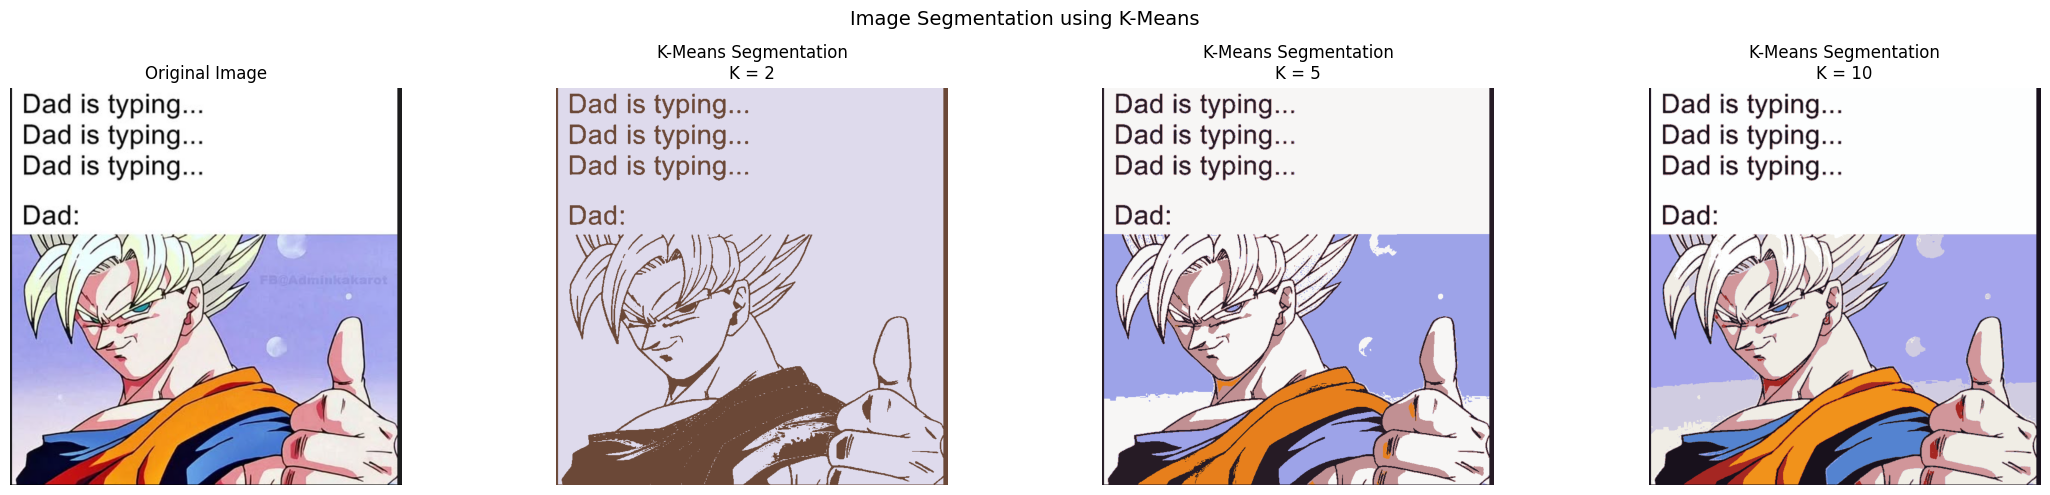

In [47]:
K_values = [2, 5, 10]
segmented_images = {}

for k in K_values:
    seg_img, km_model = segment_image(img_array, k)
    segmented_images[k] = seg_img
    print(f"K={k} done.")

# ── Display ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img_array)
axes[0].set_title('Original Image')
axes[0].axis('off')

for ax, k in zip(axes[1:], K_values):
    ax.imshow(segmented_images[k])
    ax.set_title(f'K-Means Segmentation\nK = {k}')
    ax.axis('off')

plt.suptitle('Image Segmentation using K-Means', fontsize=14)
plt.tight_layout()
plt.show()